### 1. Import bibliotek i konfiguracja

In [59]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 1
np.random.seed(RANDOM_STATE)

TYPE_LABELS = {1: 'pies', 2: 'kot'}

ADOPTION_SPEED_LABELS = {
    0: '0',
    1: '1–7',
    2: '8–30',
    3: '31–90',
    4: '>100',
}
ADOPTION_SPEED_ORDER = [ADOPTION_SPEED_LABELS[i] for i in range(5)]

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

### 2. Wczytanie danych

In [60]:
# Sciezki do folderow z danymi 
RAW_DIR = '../data/raw'
PROCESSED_DIR = '../data/processed'

# Wczytanie danych
train_df = pd.read_csv(f'{RAW_DIR}/train.csv')
breed_labels_df = pd.read_csv(f'{RAW_DIR}/breed_labels.csv')
color_labels_df = pd.read_csv(f'{RAW_DIR}/color_labels.csv')

print('train_df shape:', train_df.shape)
print('breed_labels_df shape:', breed_labels_df.shape)
print('color_labels_df shape:', color_labels_df.shape)

train_df shape: (14993, 24)
breed_labels_df shape: (307, 3)
color_labels_df shape: (7, 2)


In [61]:
# Podglad danych
display(train_df.head())
display(breed_labels_df.head())
display(color_labels_df.head())

,Type,Name,Age,Breed1,Breed2,Gender,Color1,Color2,Color3,MaturitySize,...,Health,Quantity,Fee,State,RescuerID,VideoAmt,Description,PetID,PhotoAmt,AdoptionSpeed
0,2,Nibble,3,299,0,1,1,7,0,1,...,1,1,100,41326,8480853f516546f6cf33aa88cd76c379,0,Nibble is a 3+ month old ball of cuteness. He ...,86e1089a3,1.0,2
1,2,No Name Yet,1,265,0,1,1,2,0,2,...,1,1,0,41401,3082c7125d8fb66f7dd4bff4192c8b14,0,I just found it alone yesterday near my apartm...,6296e909a,2.0,0
2,1,Brisco,1,307,0,1,2,7,0,2,...,1,1,0,41326,fa90fa5b1ee11c86938398b60abc32cb,0,Their pregnant mother was dumped by her irresp...,3422e4906,7.0,3
3,1,Miko,4,307,0,2,1,2,0,2,...,1,1,150,41401,9238e4f44c71a75282e62f7136c6b240,0,"Good guard dog, very alert, active, obedience ...",5842f1ff5,8.0,2
4,1,Hunter,1,307,0,1,1,0,0,2,...,1,1,0,41326,95481e953f8aed9ec3d16fc4509537e8,0,This handsome yet cute boy is up for adoption....,850a43f90,3.0,2


,BreedID,Type,BreedName
0,1,1,Affenpinscher
1,2,1,Afghan Hound
2,3,1,Airedale Terrier
3,4,1,Akbash
4,5,1,Akita


,ColorID,ColorName
0,1,Black
1,2,Brown
2,3,Golden
3,4,Yellow
4,5,Cream


In [62]:
print('Shape:', train_df.shape)
print('\nDtypes:')
display(train_df.dtypes)
print('\nDescribe (numeryczne):')
display(train_df.describe())
print('\nDescribe (wszystkie kolumny):')
display(train_df.describe(include='all'))

Shape: (14993, 24)

Dtypes:


Type               int64
Name                 str
Age                int64
Breed1             int64
Breed2             int64
Gender             int64
Color1             int64
Color2             int64
Color3             int64
MaturitySize       int64
FurLength          int64
Vaccinated         int64
Dewormed           int64
Sterilized         int64
Health             int64
Quantity           int64
Fee                int64
State              int64
RescuerID            str
VideoAmt           int64
Description          str
PetID                str
PhotoAmt         float64
AdoptionSpeed      int64
dtype: object


Describe (numeryczne):


,Type,Age,Breed1,Breed2,Gender,Color1,Color2,Color3,MaturitySize,FurLength,Vaccinated,Dewormed,Sterilized,Health,Quantity,Fee,State,VideoAmt,PhotoAmt,AdoptionSpeed
count,14993.000000,14993.000000,14993.000000,14993.000000,14993.000000,14993.000000,14993.000000,14993.000000,14993.000000,14993.000000,14993.000000,14993.000000,14993.000000,14993.000000,14993.000000,14993.000000,14993.000000,14993.000000,14993.000000,14993.000000
mean,1.457614,10.452078,265.272594,74.009738,1.776162,2.234176,3.222837,1.882012,1.862002,1.467485,1.731208,1.558727,1.914227,1.036617,1.576069,21.259988,41346.028347,0.056760,3.889215,2.516441
std,0.498217,18.155790,60.056818,123.011575,0.681592,1.745225,2.742562,2.984086,0.547959,0.599070,0.667649,0.695817,0.566172,0.199535,1.472477,78.414548,32.444153,0.346185,3.487810,1.177265
min,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,41324.000000,0.000000,0.000000,0.000000
25%,1.000000,2.000000,265.000000,0.000000,1.000000,1.000000,0.000000,0.000000,2.000000,1.000000,1.000000,1.000000,2.000000,1.000000,1.000000,0.000000,41326.000000,0.000000,2.000000,2.000000
50%,1.000000,3.000000,266.000000,0.000000,2.000000,2.000000,2.000000,0.000000,2.000000,1.000000,2.000000,1.000000,2.000000,1.000000,1.000000,0.000000,41326.000000,0.000000,3.000000,2.000000
75%,2.000000,12.000000,307.000000,179.000000,2.000000,3.000000,6.000000,5.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000,1.000000,0.000000,41401.000000,0.000000,5.000000,4.000000
max,2.000000,255.000000,307.000000,307.000000,3.000000,7.000000,7.000000,7.000000,4.000000,3.000000,3.000000,3.000000,3.000000,3.000000,20.000000,3000.000000,41415.000000,8.000000,30.000000,4.000000



Describe (wszystkie kolumny):


,Type,Name,Age,Breed1,Breed2,Gender,Color1,Color2,Color3,MaturitySize,...,Health,Quantity,Fee,State,RescuerID,VideoAmt,Description,PetID,PhotoAmt,AdoptionSpeed
count,14993.000000,13728,14993.000000,14993.000000,14993.000000,14993.000000,14993.000000,14993.000000,14993.000000,14993.000000,...,14993.000000,14993.000000,14993.000000,14993.000000,14993,14993.000000,14980,14993,14993.000000,14993.000000
unique,NaN,9059,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,5595,NaN,14031,14993,NaN,NaN
top,NaN,Baby,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,fa90fa5b1ee11c86938398b60abc32cb,NaN,For Adoption,86e1089a3,NaN,NaN
freq,NaN,66,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,459,NaN,164,1,NaN,NaN
mean,1.457614,NaN,10.452078,265.272594,74.009738,1.776162,2.234176,3.222837,1.882012,1.862002,...,1.036617,1.576069,21.259988,41346.028347,NaN,0.056760,NaN,NaN,3.889215,2.516441
std,0.498217,NaN,18.155790,60.056818,123.011575,0.681592,1.745225,2.742562,2.984086,0.547959,...,0.199535,1.472477,78.414548,32.444153,NaN,0.346185,NaN,NaN,3.487810,1.177265
min,1.000000,NaN,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000,...,1.000000,1.000000,0.000000,41324.000000,NaN,0.000000,NaN,NaN,0.000000,0.000000
25%,1.000000,NaN,2.000000,265.000000,0.000000,1.000000,1.000000,0.000000,0.000000,2.000000,...,1.000000,1.000000,0.000000,41326.000000,NaN,0.000000,NaN,NaN,2.000000,2.000000
50%,1.000000,NaN,3.000000,266.000000,0.000000,2.000000,2.000000,2.000000,0.000000,2.000000,...,1.000000,1.000000,0.000000,41326.000000,NaN,0.000000,NaN,NaN,3.000000,2.000000
75%,2.000000,NaN,12.000000,307.000000,179.000000,2.000000,3.000000,6.000000,5.000000,2.000000,...,1.000000,1.000000,0.000000,41401.000000,NaN,0.000000,NaN,NaN,5.000000,4.000000


### 3. Analiza danych

/tmp/ipykernel_1139/2864489232.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


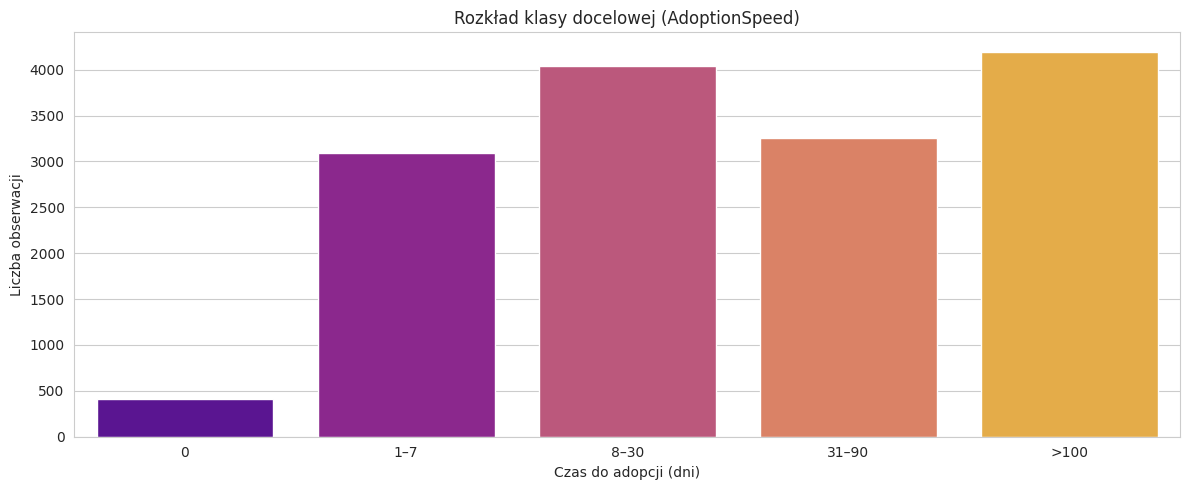

In [66]:
plot_df = train_df.assign(
    Czas_adopcji=train_df['AdoptionSpeed'].map(ADOPTION_SPEED_LABELS),
)

plt.figure(figsize=(12, 5))
sns.countplot(
    data=plot_df,
    x='Czas_adopcji',
    order=ADOPTION_SPEED_ORDER,
    palette='plasma',
)
plt.title('Rozkład klasy docelowej (AdoptionSpeed)')
plt.xlabel('Czas do adopcji (dni)')
plt.ylabel('Liczba obserwacji')
plt.tight_layout()
plt.show()

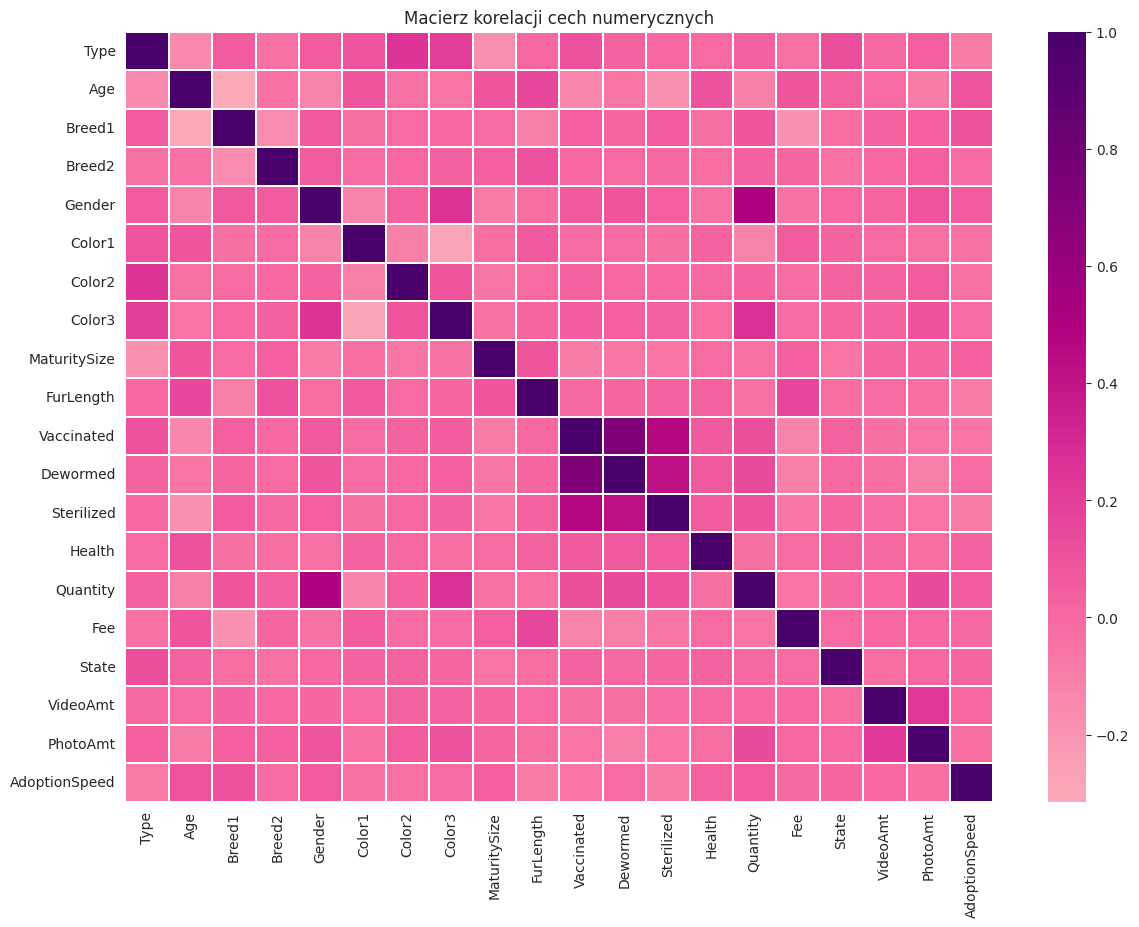

In [67]:
# Heatmapa korelacji cech numerycznych
num_cols = train_df.select_dtypes(include=[np.number]).columns
corr_matrix = train_df[num_cols].corr(numeric_only=True)

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, cmap='RdPu', center=0, linewidths=0.2)
plt.title('Macierz korelacji cech numerycznych')
plt.show()

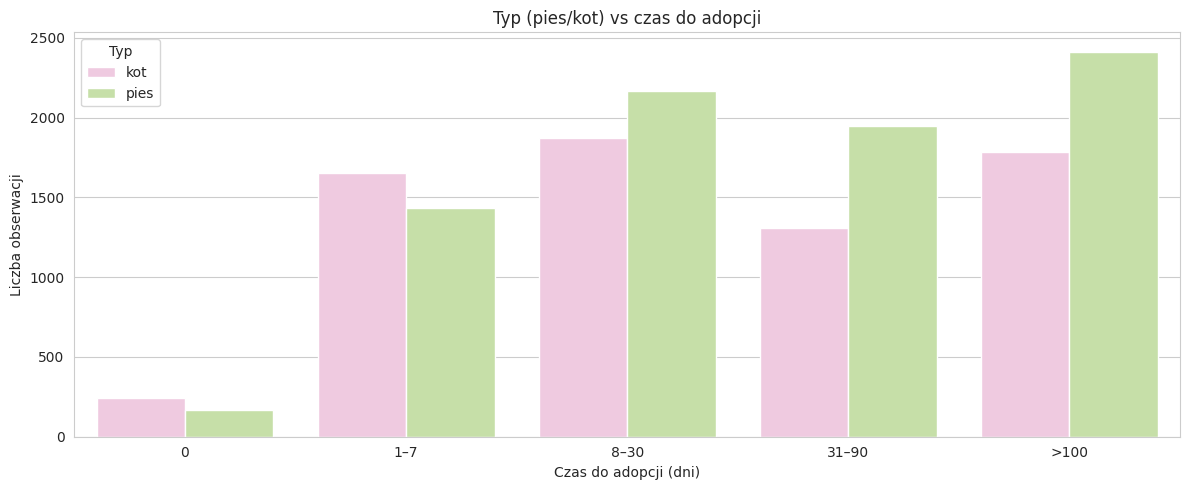

In [69]:
# Type (pies/kot) vs AdoptionSpeed
plot_df = train_df.assign(
    Typ=train_df['Type'].map(TYPE_LABELS),
    Czas_adopcji=train_df['AdoptionSpeed'].map(ADOPTION_SPEED_LABELS),
)

plt.figure(figsize=(12, 5))
sns.countplot(
    data=plot_df,
    x='Czas_adopcji',
    hue='Typ',
    order=ADOPTION_SPEED_ORDER,
    palette='PiYG',
)
plt.title('Typ (pies/kot) vs czas do adopcji')
plt.xlabel('Czas do adopcji (dni)')
plt.ylabel('Liczba obserwacji')
plt.legend(title='Typ')
plt.tight_layout()
plt.show()

In [70]:
# Brakujace wartosci w kolumnach
missing_counts = train_df.isna().sum().sort_values(ascending=False)

print('Liczba brakujacych wartosci w kazdej kolumnie:')
display(missing_counts.to_frame('liczba_brakow'))

Liczba brakujacych wartosci w kazdej kolumnie:


,liczba_brakow
Name,1265
Description,13
Age,0
Type,0
Breed2,0
Gender,0
Color1,0
Breed1,0
Color2,0
Color3,0


### 4. Czyszczenie danych

In [72]:
df_clean = train_df.copy()

# HasName: 1 gdy podano imie, 0 gdy brak
df_clean['HasName'] = df_clean['Name'].fillna('').str.strip().ne('').astype(int)

# DescLength: dlugosc opisu
df_clean['DescLength'] = df_clean['Description'].fillna('').str.len()

cols_to_drop = ['Name', 'State', 'Description']
df_clean = df_clean.drop(columns=[c for c in cols_to_drop if c in df_clean.columns])

duplicates_before = df_clean.duplicated().sum()
if duplicates_before > 0:
    df_clean = df_clean.drop_duplicates().reset_index(drop=True)

print(f'Usunieto kolumny: {cols_to_drop}')
print(f'Liczba usunietych duplikatow: {duplicates_before}')
print(f'Ksztalt df_clean: {df_clean.shape}')
display(df_clean.head())


Usunieto kolumny: ['Name', 'State', 'Description']
Liczba usunietych duplikatow: 0
Ksztalt df_clean: (14993, 23)


,Type,Age,Breed1,Breed2,Gender,Color1,Color2,Color3,MaturitySize,FurLength,...,Health,Quantity,Fee,RescuerID,VideoAmt,PetID,PhotoAmt,AdoptionSpeed,HasName,DescLength
0,2,3,299,0,1,1,7,0,1,1,...,1,1,100,8480853f516546f6cf33aa88cd76c379,0,86e1089a3,1.0,2,1,359
1,2,1,265,0,1,1,2,0,2,2,...,1,1,0,3082c7125d8fb66f7dd4bff4192c8b14,0,6296e909a,2.0,0,1,118
2,1,1,307,0,1,2,7,0,2,2,...,1,1,0,fa90fa5b1ee11c86938398b60abc32cb,0,3422e4906,7.0,3,1,393
3,1,4,307,0,2,1,2,0,2,1,...,1,1,150,9238e4f44c71a75282e62f7136c6b240,0,5842f1ff5,8.0,2,1,146
4,1,1,307,0,1,1,0,0,2,1,...,1,1,0,95481e953f8aed9ec3d16fc4509537e8,0,850a43f90,3.0,2,1,390


### 5. Zapis przetworzonych danych

In [73]:
import os
os.makedirs(PROCESSED_DIR, exist_ok=True)

output_path = f'{PROCESSED_DIR}/train_clean.csv'
df_clean.to_csv(output_path, index=False)

print('Podsumowanie przygotowania danych:')
print(f'Shape przed czyszczeniem: {train_df.shape}')
print(f'Shape po czyszczeniu: {df_clean.shape}')

print(f'Zapisano train_clean.csv')

Podsumowanie przygotowania danych:
Shape przed czyszczeniem: (14993, 24)
Shape po czyszczeniu: (14993, 23)
Zapisano train_clean.csv
